<a href="https://colab.research.google.com/github/sakshijadhav-08/AIML-Session-27-Clustering-and-PCA/blob/main/27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

Q1

In [4]:
X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

df.head(10)

,Feature1,Feature2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185
5,1.254903,-0.483435
6,1.053851,-0.442690
7,0.031380,1.053012
8,0.620545,0.713096
9,1.787657,-0.142959


In [5]:
df.shape

(500, 2)

Q2

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

X_scaled[:5]

array([[ 0.37512461, -1.40367864],
       [ 0.22681458,  1.13562771],
       [ 0.59544154, -1.49371022],
       [-0.94491835,  1.40974769],
       [-0.24311512,  1.61806199]])

Q3

In [7]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["kmeans_cluster"] = kmeans_labels

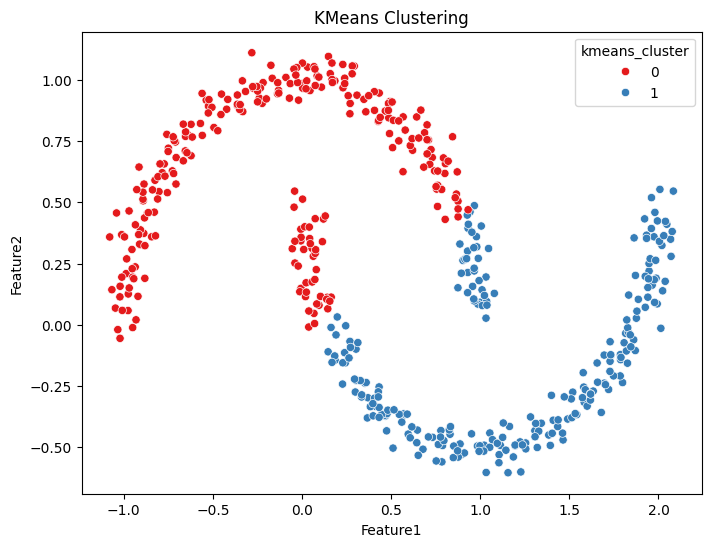

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Feature1"],
    y=df["Feature2"],
    hue=df["kmeans_cluster"],
    palette="Set1"
)

plt.title("KMeans Clustering")
plt.show()

Q4

In [9]:
dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"] = dbscan_labels

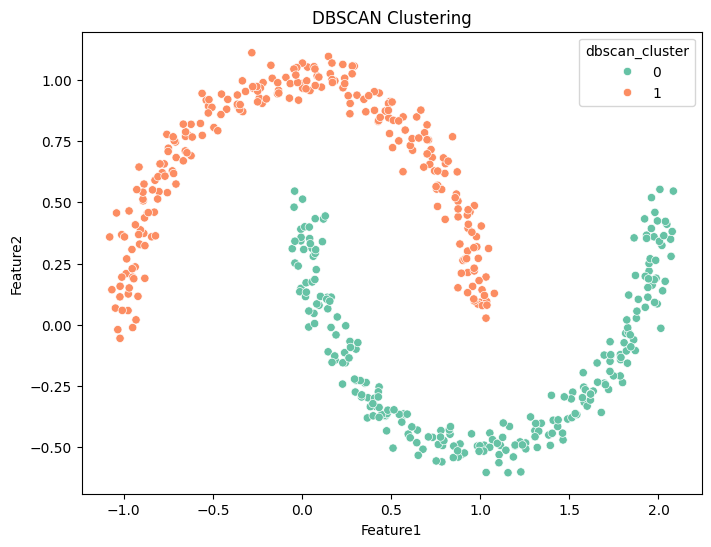

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Feature1"],
    y=df["Feature2"],
    hue=df["dbscan_cluster"],
    palette="Set2"
)

plt.title("DBSCAN Clustering")
plt.show()

Q5

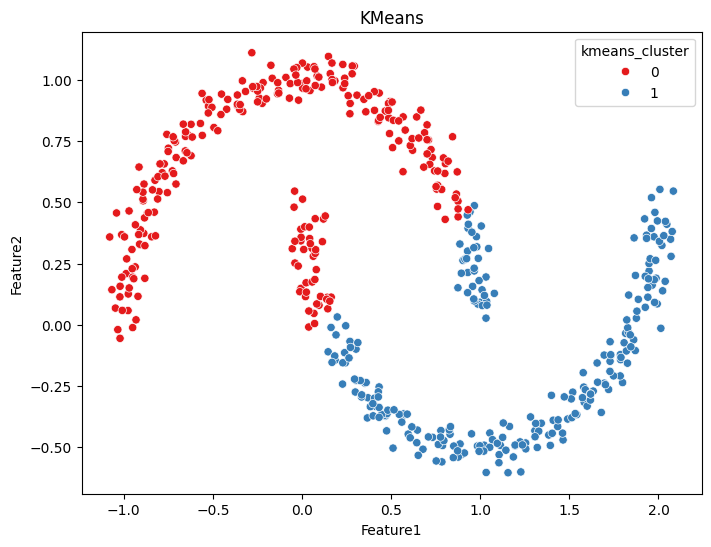

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Feature1"],
    y=df["Feature2"],
    hue=df["kmeans_cluster"],
    palette="Set1"
)

plt.title("KMeans")
plt.show()

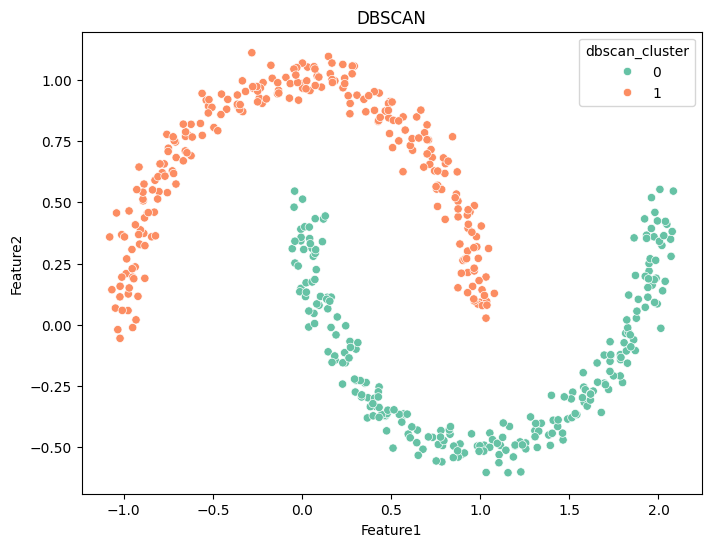

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Feature1"],
    y=df["Feature2"],
    hue=df["dbscan_cluster"],
    palette="Set2"
)

plt.title("DBSCAN")
plt.show()

Observations:

1. KMeans divides the moon dataset into two circular clusters.
2. It cannot correctly separate non-linear shapes.
3. DBSCAN identifies the moon-shaped clusters successfully.
4. DBSCAN also detects noise points if present.
5. Therefore, DBSCAN performs better for non-spherical datasets.

Q6

In [13]:
eps_values = [0.2, 0.3, 0.4, 0.5]

results = []

In [14]:
for eps in eps_values:

    db = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = db.fit_predict(X_scaled)

    clusters = len(set(labels)) - (1 if -1 in labels else 0)

    noise = list(labels).count(-1)

    results.append([eps, clusters, noise])

In [15]:
result_df = pd.DataFrame(
    results,
    columns=["eps", "No_of_Clusters", "Noise_Points"]
)

result_df

,eps,No_of_Clusters,Noise_Points
0,0.2,2,0
1,0.3,2,0
2,0.4,2,0
3,0.5,2,0


In [16]:
print("Best eps value: 0.3")

Best eps value: 0.3


Q7

In [17]:
X_blob, y_blob = make_blobs(
    n_samples=500,
    n_features=6,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

In [18]:
scaler = StandardScaler()

X_blob_scaled = scaler.fit_transform(X_blob)

Q8

In [19]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_blob_scaled)

In [20]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = y_blob

pca_df.head()

,PC1,PC2,Cluster
0,2.369765,1.259783,1
1,-0.943367,-0.829777,3
2,0.982191,-1.768556,0
3,2.265086,1.190377,1
4,2.142129,0.840804,1


In [21]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.64327878 0.21039738]


Q9

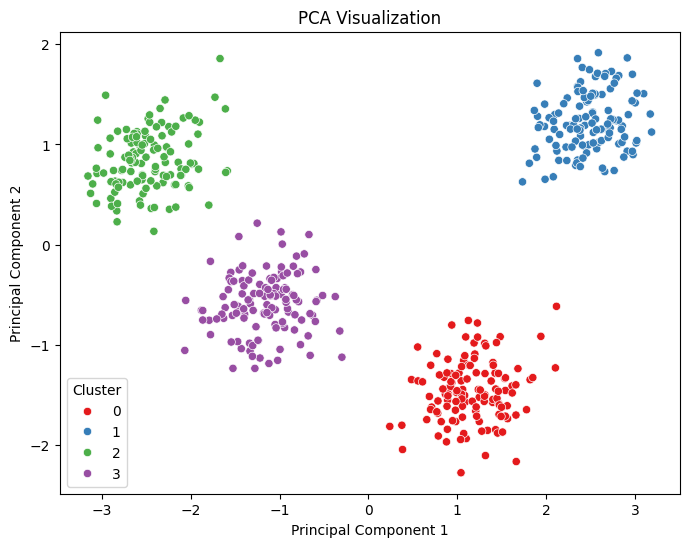

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1"
)

plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

Explained variance ratio indicates how much information
is retained after reducing the data to two dimensions.
Higher values mean less information loss.

Q10

In [23]:
from sklearn.datasets import load_iris

iris = load_iris()

iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [24]:
scaler = StandardScaler()

iris_scaled = scaler.fit_transform(iris_df)

In [25]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

clusters = dbscan.fit_predict(iris_scaled)

In [26]:
pca = PCA(n_components=2)

iris_pca = pca.fit_transform(iris_scaled)

In [27]:
iris_result = pd.DataFrame(
    iris_pca,
    columns=["PC1", "PC2"]
)

iris_result["Cluster"] = clusters

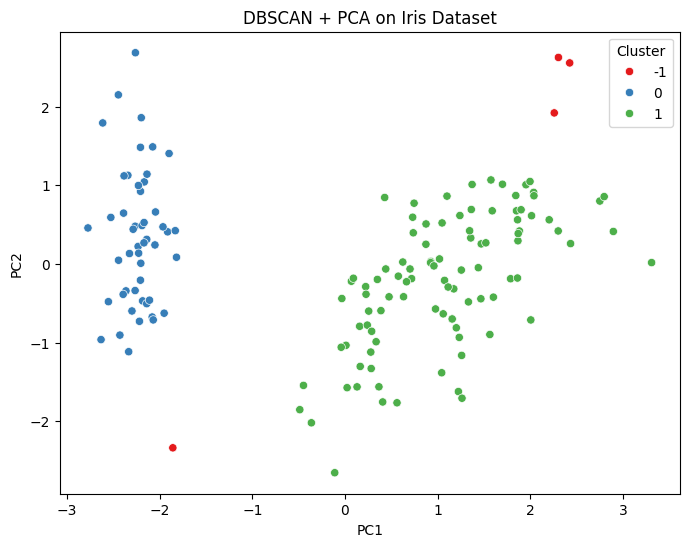

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=iris_result,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1"
)

plt.title("DBSCAN + PCA on Iris Dataset")

plt.show()